# Ensemble Models — SSU Problem Solving 2026
Decision Tree baseline에서 앙상블 기법으로 확장: RF / ExtraTrees / HistGB / XGB / LGBM → Voting → Stacking

산출물
- `answer2.csv` : train 데이터에 대한 OOF 이진 예측 (0/1) — 정직한 평가용
- `subfinal2.csv`: test 데이터에 대한 이진 예측 (0/1)

In [1]:
# Colab 전용: XGBoost / LightGBM 설치 (이미 있으면 스킵)
import subprocess, sys

def install_if_missing(pkg, import_name=None):
    import_name = import_name or pkg
    try:
        __import__(import_name)
        print(f'{pkg} already installed')
    except ImportError:
        print(f'Installing {pkg}...')
        subprocess.check_call([sys.executable, '-m', 'pip', 'install', pkg, '-q'])

install_if_missing('xgboost')
install_if_missing('lightgbm')

xgboost already installed
lightgbm already installed


In [2]:
import os
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['figure.dpi'] = 120

from sklearn.ensemble import (
    RandomForestClassifier, ExtraTreesClassifier,
    HistGradientBoostingClassifier, GradientBoostingClassifier,
    VotingClassifier, StackingClassifier
)
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import OrdinalEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.model_selection import (
    StratifiedKFold, RandomizedSearchCV, GridSearchCV,
    cross_validate, cross_val_predict
)
from sklearn.metrics import (
    roc_auc_score, balanced_accuracy_score,
    f1_score, accuracy_score
)

try:
    from xgboost import XGBClassifier
    HAS_XGB = True
except ImportError:
    HAS_XGB = False
    print('XGBoost not available')

try:
    from lightgbm import LGBMClassifier
    HAS_LGBM = True
except ImportError:
    HAS_LGBM = False
    print('LightGBM not available')

warnings.filterwarnings('ignore')
RANDOM_STATE = 42
CV = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
print(f'XGB={HAS_XGB}, LGBM={HAS_LGBM}')

XGB=True, LGBM=True


## 1. 데이터 로드

In [3]:
LOCAL_TRAIN = 'train.csv'
LOCAL_TEST  = 'test.csv'

if os.path.exists(LOCAL_TRAIN):
    train = pd.read_csv(LOCAL_TRAIN)
    test  = pd.read_csv(LOCAL_TEST) if os.path.exists(LOCAL_TEST) else None
    print(f'Local: train={train.shape}', f'test={test.shape}' if test is not None else 'no test')
else:
    import kagglehub
    path = kagglehub.competition_download('ssu-problem-solving-2026')
    train = pd.read_csv(os.path.join(path, 'train.csv'))
    test_path = os.path.join(path, 'test.csv')
    test = pd.read_csv(test_path) if os.path.exists(test_path) else None
    print(f'KaggleHub: train={train.shape}')

X_all = train.drop(columns=['target'])
y_all = train['target']

Local: train=(10000, 40) test=(2000, 39)


## 2. Feature Tier & 공통 유틸

In [4]:
# Adversarial validation 기반: 전이 불가 feature 제거, 전이 가능 feature만 사용
DROP_ID_LIKE = ['id', 'feat_08', 'feat_09', 'feat_14', 'feat_24', 'feat_34', 'feat_38']  # adv_auc~=1.0
CORE6 = ['feat_05', 'feat_31', 'feat_07', 'feat_02', 'feat_36']           # TRANSFER_CORE (adv_auc<0.55)
CORE7 = CORE6 + ['feat_01']   # TRANSFER_PLUS01: covariate shift 있으나 P(y|x) 보존
ALL34 = [c for c in train.columns if c not in DROP_ID_LIKE + ['target']]  # ALL_TRANSFER (32개)

TIERS = {'ALL34': ALL34, 'CORE7': CORE7, 'CORE6': CORE6}

def get_cat(cols):
    return [c for c in cols if train[c].dtype == object]

def build_pipe(feature_cols, model):
    """OrdinalEncoder 파이프라인 (수치형 pass-through)."""
    cat = get_cat(feature_cols)
    if cat:
        enc = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)
        ct  = ColumnTransformer([('ord', enc, cat)], remainder='passthrough',
                                verbose_feature_names_out=False)
        return Pipeline([('prep', ct), ('clf', model)])
    return Pipeline([('clf', model)])

def evaluate(model, feature_cols, cv=CV, return_train=True):
    """5-fold CV → {metric: {cv_mean, cv_std, train_mean, gap}} 반환."""
    X = train[feature_cols]
    y = train['target']
    pipe = build_pipe(feature_cols, model)
    scoring = {
        'roc_auc': 'roc_auc',
        'balanced_accuracy': 'balanced_accuracy',
        'f1_macro': 'f1_macro',
        'accuracy': 'accuracy',
    }
    res = cross_validate(pipe, X, y, cv=cv, scoring=scoring,
                         return_train_score=return_train, n_jobs=-1)
    out = {}
    for m in scoring:
        cv_s  = res[f'test_{m}']
        tr_s  = res[f'train_{m}'] if return_train else np.array([np.nan])
        out[m] = dict(cv_mean=cv_s.mean(), cv_std=cv_s.std(),
                      train_mean=tr_s.mean(), gap=tr_s.mean()-cv_s.mean())
    return out

def fmt(res):
    auc = res['roc_auc']
    acc = res['accuracy']
    return (f"AUC={auc['cv_mean']:.4f}±{auc['cv_std']:.4f} "
            f"Acc={acc['cv_mean']:.4f} Gap={auc['gap']:.4f}")

print('Tier 정의 완료:', {k: len(v) for k, v in TIERS.items()})

Tier 정의 완료: {'ALL34': 32, 'CORE7': 6, 'CORE6': 5}


## 3. 앙상블 모델 기본 성능 비교 (ALL34 tier)

In [5]:
# 기본 하이퍼파라미터로 주요 앙상블 모델 비교
base_models = {
    'RandomForest':  RandomForestClassifier(n_estimators=300, class_weight='balanced',
                                             random_state=RANDOM_STATE, n_jobs=-1),
    'ExtraTrees':    ExtraTreesClassifier(n_estimators=300, class_weight='balanced',
                                          random_state=RANDOM_STATE, n_jobs=-1),
    'HistGB':        HistGradientBoostingClassifier(max_iter=300, random_state=RANDOM_STATE),
}

if HAS_XGB:
    scale_pw = (y_all == 0).sum() / (y_all == 1).sum()
    base_models['XGBoost'] = XGBClassifier(n_estimators=300, scale_pos_weight=scale_pw,
                                            random_state=RANDOM_STATE, n_jobs=-1,
                                            eval_metric='logloss', verbosity=0)
if HAS_LGBM:
    base_models['LightGBM'] = LGBMClassifier(n_estimators=300, class_weight='balanced',
                                              random_state=RANDOM_STATE, n_jobs=-1,
                                              verbosity=-1)

base_results = {}
print(f"{'Model':<15} {'CV AUC':>10} {'±std':>7} {'Train AUC':>10} {'Gap':>7} {'CV Acc':>8}")
print('-' * 60)

for name, model in base_models.items():
    res = evaluate(model, ALL34)
    base_results[name] = res
    auc = res['roc_auc']
    acc = res['accuracy']
    print(f"{name:<15} {auc['cv_mean']:>10.4f} {auc['cv_std']:>7.4f} "
          f"{auc['train_mean']:>10.4f} {auc['gap']:>7.4f} {acc['cv_mean']:>8.4f}")

Model               CV AUC    ±std  Train AUC     Gap   CV Acc
------------------------------------------------------------
RandomForest        0.6572  0.0113     1.0000  0.3428   0.7405
ExtraTrees          0.6635  0.0152     1.0000  0.3365   0.7379
HistGB              0.6524  0.0190     1.0000  0.3476   0.7251
XGBoost             0.6546  0.0143     1.0000  0.3454   0.6990
LightGBM            0.6573  0.0151     1.0000  0.3427   0.7050


## 4. Tier 비교 (RF & HistGB)

In [6]:
# RF와 HistGB에 대해 3 tier 비교
tier_compare = {}
print(f"{'Model+Tier':<22} {'CV AUC':>10} {'±std':>7} {'Gap':>7} {'CV Acc':>8}")
print('-' * 58)

for tier_name, feats in TIERS.items():
    for mname, model_cls in [
        ('RF',     lambda: RandomForestClassifier(n_estimators=300, class_weight='balanced',
                                                  random_state=RANDOM_STATE, n_jobs=-1)),
        ('HistGB', lambda: HistGradientBoostingClassifier(max_iter=300, random_state=RANDOM_STATE)),
    ]:
        key = f'{mname}_{tier_name}'
        res = evaluate(model_cls(), feats)
        tier_compare[key] = (mname, tier_name, res)
        auc = res['roc_auc']
        acc = res['accuracy']
        print(f"{key:<22} {auc['cv_mean']:>10.4f} {auc['cv_std']:>7.4f} "
              f"{auc['gap']:>7.4f} {acc['cv_mean']:>8.4f}")

Model+Tier                 CV AUC    ±std     Gap   CV Acc
----------------------------------------------------------
RF_ALL34                   0.6572  0.0113  0.3428   0.7405
HistGB_ALL34               0.6524  0.0190  0.3476   0.7251
RF_CORE7                   0.6561  0.0138  0.3439   0.7315
HistGB_CORE7               0.6600  0.0176  0.3133   0.7162
RF_CORE6                   0.6326  0.0168  0.3674   0.6983
HistGB_CORE6               0.6416  0.0163  0.3093   0.6962


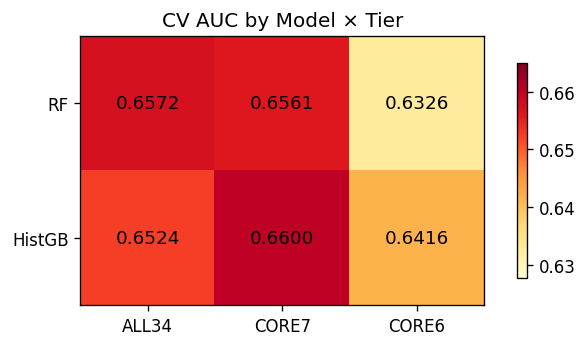

Saved: tier_heatmap.png


In [7]:
# Tier × 모델 AUC 히트맵
tier_order  = list(TIERS.keys())
model_order = ['RF', 'HistGB']
auc_matrix  = np.array([
    [tier_compare[f'{m}_{t}'][2]['roc_auc']['cv_mean'] for t in tier_order]
    for m in model_order
])

fig, ax = plt.subplots(figsize=(6, 3))
im = ax.imshow(auc_matrix, cmap='YlOrRd', vmin=auc_matrix.min()-0.005, vmax=auc_matrix.max()+0.005)
ax.set_xticks(range(len(tier_order)));  ax.set_xticklabels(tier_order)
ax.set_yticks(range(len(model_order))); ax.set_yticklabels(model_order)
for i in range(len(model_order)):
    for j in range(len(tier_order)):
        ax.text(j, i, f'{auc_matrix[i,j]:.4f}', ha='center', va='center', fontsize=11)
plt.colorbar(im, ax=ax, shrink=0.8)
ax.set_title('CV AUC by Model × Tier')
plt.tight_layout()
plt.savefig('tier_heatmap.png', bbox_inches='tight')
plt.show()
print('Saved: tier_heatmap.png')

## 5. 최적 모델·Tier 선택 & 하이퍼파라미터 튜닝

In [8]:
# 전체 결과(base + tier_compare)에서 CV AUC 최고 조합 자동 선택
all_candidates = {}
for name, res in base_results.items():
    all_candidates[(name, 'ALL34')] = res
for key, (mname, tname, res) in tier_compare.items():
    all_candidates[(mname, tname)] = res

best_key = max(all_candidates, key=lambda k: all_candidates[k]['roc_auc']['cv_mean'])
best_model_name, best_tier_name = best_key
best_feats = TIERS.get(best_tier_name, ALL34)
best_auc   = all_candidates[best_key]['roc_auc']['cv_mean']
print(f'Best: model={best_model_name}, tier={best_tier_name}, CV AUC={best_auc:.4f}')
print(f'Feature 수: {len(best_feats)}')

Best: model=ExtraTrees, tier=ALL34, CV AUC=0.6635
Feature 수: 32


In [9]:
# 튜닝 대상 모델 정의
X_tune = train[best_feats]
y_tune = train['target']

# 모델별 탐색 공간
SEARCH_SPACE = {
    'RandomForest': {
        'model': RandomForestClassifier(random_state=RANDOM_STATE, n_jobs=-1),
        'params': {
            'clf__n_estimators':      [200, 400, 600],
            'clf__max_depth':         [None, 10, 20, 30],
            'clf__min_samples_leaf':  [1, 3, 5, 10],
            'clf__max_features':      ['sqrt', 'log2', 0.5],
            'clf__class_weight':      [None, 'balanced', 'balanced_subsample'],
        }
    },
    'ExtraTrees': {
        'model': ExtraTreesClassifier(random_state=RANDOM_STATE, n_jobs=-1),
        'params': {
            'clf__n_estimators':      [200, 400, 600],
            'clf__max_depth':         [None, 15, 30],
            'clf__min_samples_leaf':  [1, 3, 5],
            'clf__max_features':      ['sqrt', 'log2', 0.5],
            'clf__class_weight':      [None, 'balanced'],
        }
    },
    'HistGB': {
        'model': HistGradientBoostingClassifier(random_state=RANDOM_STATE),
        'params': {
            'clf__max_iter':          [200, 400, 600],
            'clf__max_depth':         [None, 4, 6, 8],
            'clf__learning_rate':     [0.01, 0.05, 0.1, 0.2],
            'clf__min_samples_leaf':  [10, 20, 40],
            'clf__l2_regularization': [0.0, 0.1, 1.0],
            'clf__class_weight':      [None, 'balanced'],
        }
    },
}

if HAS_XGB:
    spw = (y_tune == 0).sum() / (y_tune == 1).sum()
    SEARCH_SPACE['XGBoost'] = {
        'model': XGBClassifier(random_state=RANDOM_STATE, n_jobs=-1,
                               eval_metric='logloss', verbosity=0),
        'params': {
            'clf__n_estimators':   [200, 400, 600],
            'clf__max_depth':      [3, 5, 7],
            'clf__learning_rate':  [0.01, 0.05, 0.1],
            'clf__subsample':      [0.7, 0.85, 1.0],
            'clf__colsample_bytree': [0.7, 0.85, 1.0],
            'clf__scale_pos_weight': [1.0, spw],
            'clf__reg_alpha':      [0, 0.1, 1.0],
            'clf__reg_lambda':     [1.0, 2.0, 5.0],
        }
    }

if HAS_LGBM:
    SEARCH_SPACE['LightGBM'] = {
        'model': LGBMClassifier(random_state=RANDOM_STATE, n_jobs=-1, verbosity=-1),
        'params': {
            'clf__n_estimators':   [200, 400, 600],
            'clf__max_depth':      [-1, 5, 8],
            'clf__learning_rate':  [0.01, 0.05, 0.1],
            'clf__num_leaves':     [15, 31, 63],
            'clf__subsample':      [0.7, 0.85, 1.0],
            'clf__class_weight':   [None, 'balanced'],
            'clf__reg_alpha':      [0, 0.1, 1.0],
        }
    }

# best_model_name이 SEARCH_SPACE에 없으면 HistGB 기본
tune_name = best_model_name if best_model_name in SEARCH_SPACE else 'HistGB'
print(f'튜닝 대상: {tune_name}')

튜닝 대상: ExtraTrees


In [10]:
# RandomizedSearchCV
sp = SEARCH_SPACE[tune_name]
pipe_tune = build_pipe(best_feats, sp['model'])

rs = RandomizedSearchCV(
    pipe_tune, sp['params'],
    n_iter=100,
    scoring='roc_auc',
    cv=CV,
    random_state=RANDOM_STATE,
    n_jobs=-1,
    refit=True,
    verbose=1,
)
rs.fit(X_tune, y_tune)

print(f'\nBest CV AUC: {rs.best_score_:.4f}')
print('Best params:')
for k, v in rs.best_params_.items():
    print(f'  {k}: {v}')

Fitting 5 folds for each of 100 candidates, totalling 500 fits

Best CV AUC: 0.6668
Best params:
  clf__n_estimators: 600
  clf__min_samples_leaf: 1
  clf__max_features: sqrt
  clf__max_depth: 15
  clf__class_weight: None


In [11]:
# 튜닝 결과 전체 재평가
best_params_clean = {k.replace('clf__', ''): v for k, v in rs.best_params_.items()}

def make_tuned_model():
    model_map = {
        'RandomForest': RandomForestClassifier,
        'ExtraTrees':   ExtraTreesClassifier,
        'HistGB':       HistGradientBoostingClassifier,
    }
    if HAS_XGB: model_map['XGBoost']  = XGBClassifier
    if HAS_LGBM: model_map['LightGBM'] = LGBMClassifier
    cls = model_map[tune_name]
    return cls(random_state=RANDOM_STATE, **best_params_clean)

tuned_model = make_tuned_model()
tuned_res   = evaluate(tuned_model, best_feats)
auc = tuned_res['roc_auc']
acc = tuned_res['accuracy']
print(f'Tuned {tune_name}({best_tier_name}):'
      f' AUC={auc["cv_mean"]:.4f}±{auc["cv_std"]:.4f}'
      f' Gap={auc["gap"]:.4f}'
      f' Acc={acc["cv_mean"]:.4f}')

Tuned ExtraTrees(ALL34): AUC=0.6668±0.0105 Gap=0.3318 Acc=0.7385


## 6. Soft Voting Ensemble (상위 모델 결합)

In [12]:
# 각 base 모델 중 CV AUC 상위 3개를 Soft Voting으로 결합
# (파이프라인 내부 clf가 VotingClassifier이면 중첩 파이프라인이므로
#  전처리된 데이터를 VotingClassifier에 직접 넘기는 방식으로 처리)

# Soft Voting용 Voter 구성: 튜닝 모델 + RF(balanced) + HistGB
voter_components = [
    ('tuned', make_tuned_model()),
    ('rf',    RandomForestClassifier(n_estimators=400, class_weight='balanced',
                                     max_features='sqrt', random_state=RANDOM_STATE, n_jobs=-1)),
    ('hgb',   HistGradientBoostingClassifier(max_iter=400, learning_rate=0.05,
                                              random_state=RANDOM_STATE)),
]

if HAS_XGB:
    spw = (y_all == 0).sum() / (y_all == 1).sum()
    voter_components.append((
        'xgb', XGBClassifier(n_estimators=300, learning_rate=0.05, max_depth=5,
                              scale_pos_weight=spw, random_state=RANDOM_STATE,
                              n_jobs=-1, eval_metric='logloss', verbosity=0)
    ))

if HAS_LGBM:
    voter_components.append((
        'lgbm', LGBMClassifier(n_estimators=300, learning_rate=0.05, num_leaves=31,
                                class_weight='balanced', random_state=RANDOM_STATE,
                                n_jobs=-1, verbosity=-1)
    ))

voter = VotingClassifier(estimators=voter_components, voting='soft', n_jobs=-1)
vote_res = evaluate(voter, best_feats)
auc_v = vote_res['roc_auc']
acc_v = vote_res['accuracy']
print(f'SoftVoting: AUC={auc_v["cv_mean"]:.4f}±{auc_v["cv_std"]:.4f}'
      f' Gap={auc_v["gap"]:.4f} Acc={acc_v["cv_mean"]:.4f}')

SoftVoting: AUC=0.6599±0.0176 Gap=0.3395 Acc=0.7401


## 7. Stacking Ensemble

In [13]:
# Level-0: RF + HistGB + ExtraTrees (+ XGB/LGBM if available)
# Level-1: LogisticRegression (meta-learner)
l0_estimators = [
    ('rf',  RandomForestClassifier(n_estimators=300, class_weight='balanced',
                                   random_state=RANDOM_STATE, n_jobs=-1)),
    ('et',  ExtraTreesClassifier(n_estimators=300, class_weight='balanced',
                                 random_state=RANDOM_STATE, n_jobs=-1)),
    ('hgb', HistGradientBoostingClassifier(max_iter=300, random_state=RANDOM_STATE)),
]

if HAS_XGB:
    spw = (y_all == 0).sum() / (y_all == 1).sum()
    l0_estimators.append((
        'xgb', XGBClassifier(n_estimators=200, learning_rate=0.05, max_depth=5,
                              scale_pos_weight=spw, random_state=RANDOM_STATE,
                              n_jobs=-1, eval_metric='logloss', verbosity=0)
    ))
if HAS_LGBM:
    l0_estimators.append((
        'lgbm', LGBMClassifier(n_estimators=200, learning_rate=0.05, num_leaves=31,
                                class_weight='balanced', random_state=RANDOM_STATE,
                                n_jobs=-1, verbosity=-1)
    ))

stacker = StackingClassifier(
    estimators=l0_estimators,
    final_estimator=LogisticRegression(C=1.0, max_iter=500, random_state=RANDOM_STATE),
    cv=5,
    stack_method='predict_proba',
    passthrough=False,
    n_jobs=-1,
)
stack_res = evaluate(stacker, best_feats, return_train=False)
auc_s = stack_res['roc_auc']
acc_s = stack_res['accuracy']
print(f'Stacking:   AUC={auc_s["cv_mean"]:.4f}±{auc_s["cv_std"]:.4f}'
      f' Acc={acc_s["cv_mean"]:.4f}')

Stacking:   AUC=0.6602±0.0145 Acc=0.7420


## 8. 최종 모델 비교 & 선택

In [14]:
comparison = {
    f'Tuned {tune_name}': tuned_res,
    'SoftVoting':          vote_res,
    'Stacking':            stack_res,
}
# base models 추가
for name, res in base_results.items():
    comparison[f'Base {name}'] = res

rows = []
for name, res in comparison.items():
    auc = res['roc_auc']
    acc = res['accuracy']
    bacc = res['balanced_accuracy']
    f1   = res['f1_macro']
    rows.append({
        'Model': name,
        'CV AUC': auc['cv_mean'],
        '±std':   auc['cv_std'],
        'Gap':    auc['gap'],
        'CV Acc': acc['cv_mean'],
        'Balanced Acc': bacc['cv_mean'],
        'F1-macro': f1['cv_mean'],
    })

comp_df = pd.DataFrame(rows).sort_values('CV AUC', ascending=False).reset_index(drop=True)
print(comp_df.to_string(index=False, float_format='{:.4f}'.format))

champion_name = comp_df.iloc[0]['Model']
print(f'\nChampion: {champion_name}  (AUC={comp_df.iloc[0]["CV AUC"]:.4f})')

            Model  CV AUC   ±std    Gap  CV Acc  Balanced Acc  F1-macro
 Tuned ExtraTrees  0.6668 0.0105 0.3318  0.7385        0.6530    0.6613
  Base ExtraTrees  0.6635 0.0152 0.3365  0.7379        0.6516    0.6596
         Stacking  0.6602 0.0145    NaN  0.7420        0.6597    0.6691
       SoftVoting  0.6599 0.0176 0.3395  0.7401        0.6593    0.6685
    Base LightGBM  0.6573 0.0151 0.3427  0.7050        0.6393    0.6454
Base RandomForest  0.6572 0.0113 0.3428  0.7405        0.6564    0.6653
     Base XGBoost  0.6546 0.0143 0.3454  0.6990        0.6336    0.6391
      Base HistGB  0.6524 0.0190 0.3476  0.7251        0.6447    0.6519

Champion: Tuned ExtraTrees  (AUC=0.6668)


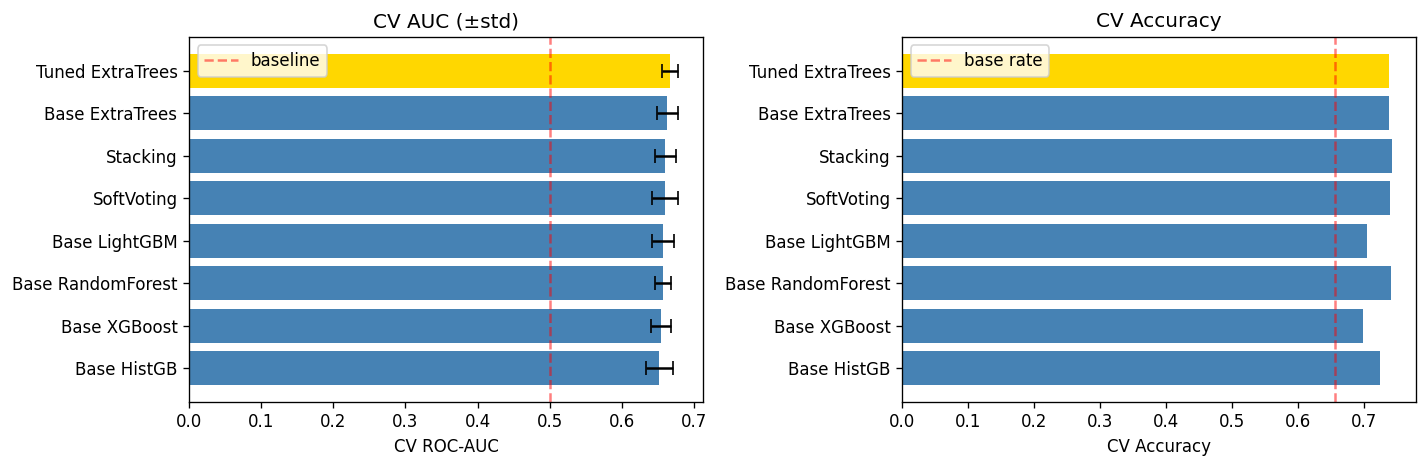

Saved: ensemble_comparison.png


In [15]:
# 비교 막대그래프
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
models_plot = comp_df['Model'].tolist()
aucs_plot   = comp_df['CV AUC'].tolist()
stds_plot   = comp_df['±std'].tolist()
accs_plot   = comp_df['CV Acc'].tolist()

colors = ['gold' if m == champion_name else 'steelblue' for m in models_plot]

axes[0].barh(models_plot[::-1], aucs_plot[::-1], xerr=stds_plot[::-1],
             color=colors[::-1], capsize=4)
axes[0].set_xlabel('CV ROC-AUC'); axes[0].set_title('CV AUC (±std)')
axes[0].axvline(0.5, color='red', linestyle='--', alpha=0.5, label='baseline')
axes[0].legend()

axes[1].barh(models_plot[::-1], accs_plot[::-1], color=colors[::-1])
axes[1].set_xlabel('CV Accuracy'); axes[1].set_title('CV Accuracy')
axes[1].axvline(0.657, color='red', linestyle='--', alpha=0.5, label='base rate')
axes[1].legend()

plt.tight_layout()
plt.savefig('ensemble_comparison.png', bbox_inches='tight')
plt.show()
print('Saved: ensemble_comparison.png')

## 9. Feature Importance (Champion 모델)

Tuned ExtraTrees → full train 학습 완료


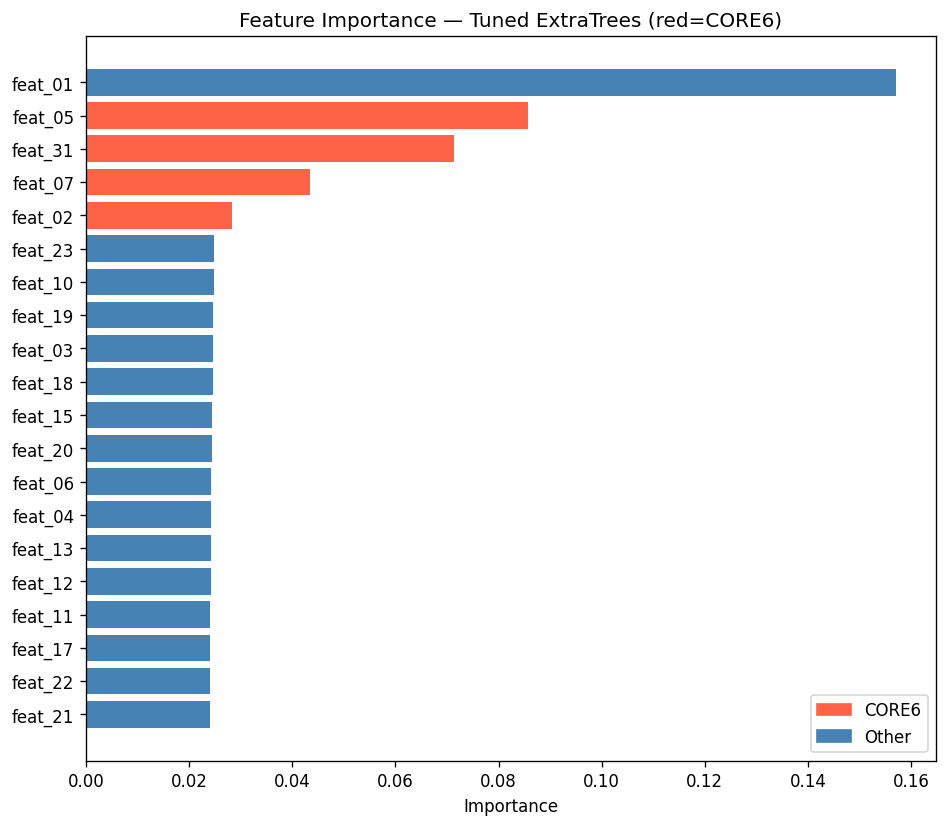

Saved: feature_importance_ensemble.png
feature  importance
feat_01    0.157003
feat_05    0.085641
feat_31    0.071305
feat_07    0.043475
feat_02    0.028240
feat_23    0.024873
feat_10    0.024854
feat_19    0.024719
feat_03    0.024580
feat_18    0.024577


In [16]:
# Champion 파이프라인을 전체 train으로 학습
champion_map = {
    f'Tuned {tune_name}': build_pipe(best_feats, make_tuned_model()),
    'SoftVoting':          build_pipe(best_feats, voter),
    'Stacking':            build_pipe(best_feats, stacker),
    **{f'Base {n}': build_pipe(best_feats, m) for n, m in base_models.items()}
}

champion_pipe = champion_map.get(champion_name,
                                  build_pipe(best_feats, make_tuned_model()))
champion_pipe.fit(train[best_feats], train['target'])
print(f'{champion_name} → full train 학습 완료')

# Feature importance 추출 (단일 추정기에서만 가능)
def extract_importance(pipe, feature_cols):
    clf = pipe.named_steps.get('clf')
    if clf is None:
        return None
    # VotingClassifier / StackingClassifier는 직접 importances 없음
    if hasattr(clf, 'feature_importances_'):
        fn = (pipe.named_steps['prep'].get_feature_names_out()
              if 'prep' in pipe.named_steps else np.array(feature_cols))
        return pd.DataFrame({'feature': fn,
                             'importance': clf.feature_importances_}
                            ).sort_values('importance', ascending=False)
    # VotingClassifier: 내부 추정기 중 첫 번째 RF/ET 활용
    if hasattr(clf, 'estimators_'):
        for est_name, est in clf.estimators_:
            if hasattr(est, 'feature_importances_'):
                fn = (pipe.named_steps['prep'].get_feature_names_out()
                      if 'prep' in pipe.named_steps else np.array(feature_cols))
                return pd.DataFrame({'feature': fn,
                                     'importance': est.feature_importances_}
                                    ).sort_values('importance', ascending=False)
    return None

fi_df = extract_importance(champion_pipe, best_feats)

if fi_df is not None:
    top_n = min(20, len(fi_df))
    fi_top = fi_df.head(top_n)
    colors_fi = ['tomato' if f in CORE6 else 'steelblue' for f in fi_top['feature']]

    fig, ax = plt.subplots(figsize=(8, max(4, top_n * 0.35)))
    ax.barh(fi_top['feature'][::-1], fi_top['importance'][::-1], color=colors_fi[::-1])
    ax.set_xlabel('Importance')
    ax.set_title(f'Feature Importance — {champion_name} (red=CORE6)')
    from matplotlib.patches import Patch
    ax.legend(handles=[Patch(color='tomato', label='CORE6'),
                        Patch(color='steelblue', label='Other')], loc='lower right')
    plt.tight_layout()
    plt.savefig('feature_importance_ensemble.png', bbox_inches='tight')
    plt.show()
    print('Saved: feature_importance_ensemble.png')
    print(fi_df.head(10).to_string(index=False))
else:
    fi_df = pd.DataFrame()
    print('Feature importance는 VotingClassifier/Stacking 전체에서 추출 불가 → 개별 추정기 값 사용')

## 10. answer2.csv — train OOF 이진 예측 (0/1)

In [17]:
# OOF(Out-of-Fold) 예측: 각 샘플이 훈련에 사용되지 않은 fold에서 예측
# → 정직한 train-set 성능 평가 가능
print('OOF 이진 예측 생성 중...')

oof_pipe = build_pipe(best_feats, make_tuned_model())
oof_proba = cross_val_predict(
    oof_pipe,
    train[best_feats],
    train['target'],
    cv=CV,
    method='predict_proba',
    n_jobs=-1,
)[:, 1]

# 최적 임계값 탐색 (Balanced Accuracy 기준)
from sklearn.metrics import balanced_accuracy_score
thresholds = np.arange(0.25, 0.75, 0.01)
bacc_scores = [balanced_accuracy_score(train['target'], (oof_proba >= t).astype(int))
               for t in thresholds]
best_threshold = thresholds[np.argmax(bacc_scores)]
print(f'최적 임계값 (Balanced Acc 기준): {best_threshold:.2f}')

oof_binary = (oof_proba >= best_threshold).astype(int)

oof_auc  = roc_auc_score(train['target'], oof_proba)
oof_acc  = accuracy_score(train['target'], oof_binary)
oof_bacc = balanced_accuracy_score(train['target'], oof_binary)
oof_f1   = f1_score(train['target'], oof_binary, average='macro')

print(f'OOF AUC={oof_auc:.4f} Acc={oof_acc:.4f} BalancedAcc={oof_bacc:.4f} F1-macro={oof_f1:.4f}')
print(f'예측 분포: 0={int((oof_binary==0).sum())} 1={int((oof_binary==1).sum())}')
print(f'실제 분포: 0={(train["target"]==0).sum()} 1={(train["target"]==1).sum()}')

OOF 이진 예측 생성 중...
최적 임계값 (Balanced Acc 기준): 0.42
OOF AUC=0.6665 Acc=0.7403 BalancedAcc=0.6612 F1-macro=0.6707
예측 분포: 0=8029 1=1971
실제 분포: 0=6568 1=3432


Saved: answer2.csv  (10000행, threshold=0.42)
     id  target
0  6252       0
1  4684       0
2  1731       0
3  4742       0
4  4521       0


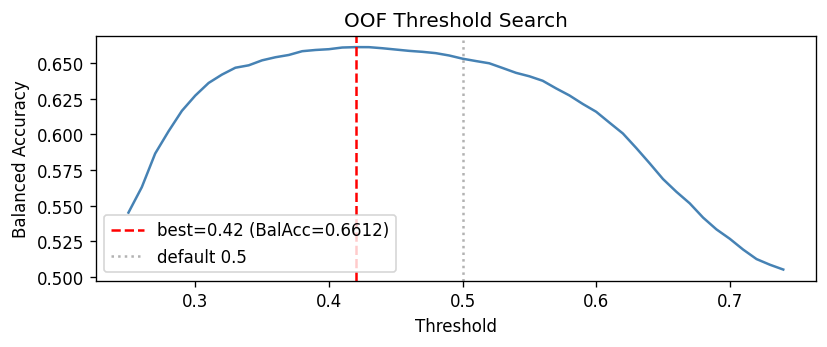

Saved: threshold_search.png


In [18]:
# answer2.csv 저장
answer2 = pd.DataFrame({
    'id':     train['id'],
    'target': oof_binary,
})
answer2.to_csv('answer2.csv', index=False)
print(f'Saved: answer2.csv  ({len(answer2)}행, threshold={best_threshold:.2f})')
print(answer2.head())

# 임계값 탐색 시각화
fig, ax = plt.subplots(figsize=(7, 3))
ax.plot(thresholds, bacc_scores, color='steelblue')
ax.axvline(best_threshold, color='red', linestyle='--',
           label=f'best={best_threshold:.2f} (BalAcc={max(bacc_scores):.4f})')
ax.axvline(0.5, color='gray', linestyle=':', alpha=0.6, label='default 0.5')
ax.set_xlabel('Threshold'); ax.set_ylabel('Balanced Accuracy')
ax.set_title('OOF Threshold Search')
ax.legend()
plt.tight_layout()
plt.savefig('threshold_search.png', bbox_inches='tight')
plt.show()
print('Saved: threshold_search.png')

## 11. subfinal2.csv — test 이진 예측 (0/1)

In [19]:
if test is not None:
    X_test = test[best_feats]

    # 전체 train으로 재학습
    final_pipe = build_pipe(best_feats, make_tuned_model())
    final_pipe.fit(train[best_feats], train['target'])

    test_proba  = final_pipe.predict_proba(X_test)[:, 1]
    test_binary = (test_proba >= best_threshold).astype(int)

    subfinal2 = pd.DataFrame({'id': test['id'], 'target': test_binary})

    # sample_submission 컬럼 순서 맞춤
    if os.path.exists('sample_submission.csv'):
        ss = pd.read_csv('sample_submission.csv')
        subfinal2 = subfinal2[ss.columns]

    subfinal2.to_csv('subfinal2.csv', index=False)
    print(f'Saved: subfinal2.csv  ({len(subfinal2)}행)')
    print(subfinal2['target'].value_counts().sort_index())
    print(subfinal2.head())
else:
    print('test.csv 없음 → subfinal2.csv 생성 건너뜀')

Saved: subfinal2.csv  (2000행)
target
0    1707
1     293
Name: count, dtype: int64
      id  target
0  10097       0
1  11150       0
2  11596       0
3  11007       1
4  10120       0


## 12. results_model2.md 저장

In [20]:
top5_fi = fi_df.head(5)['feature'].tolist() if not fi_df.empty else ['N/A']

md = []
md.append('# 앙상블 모델 결과 요약 — SSU Problem Solving 2026\n')
md.append('생성일: 2026-06-02  |  random_state=42\n')

md.append('\n## (a) 모델별 CV 성능 비교\n')
md.append('| Model | CV AUC | ±std | Gap | CV Acc | Bal.Acc | F1-macro |')
md.append('|-------|--------|------|-----|--------|---------|----------|')
for _, row in comp_df.iterrows():
    champ_tag = ' ★' if row['Model'] == champion_name else ''
    md.append(
        f"| {row['Model']}{champ_tag} "
        f"| {row['CV AUC']:.4f} | {row['±std']:.4f} | {row['Gap']:.4f} "
        f"| {row['CV Acc']:.4f} | {row['Balanced Acc']:.4f} | {row['F1-macro']:.4f} |"
    )
md.append('\n★ = Champion 모델')

md.append('\n\n## (b) 최적 하이퍼파라미터\n')
md.append(f'- 모델: **{tune_name}** | Tier: **{best_tier_name}** | Feature 수: {len(best_feats)}')
for k, v in best_params_clean.items():
    md.append(f'- `{k}` = `{v}`')

md.append('\n\n## (c) Feature Importance 상위 10개\n')
if not fi_df.empty:
    md.append('| 순위 | Feature | Importance |')
    md.append('|------|---------|------------|')
    for i, (_, row) in enumerate(fi_df.head(10).iterrows(), 1):
        tag = ' ★' if row['feature'] in CORE6 else ''
        md.append(f"| {i} | {row['feature']}{tag} | {row['importance']:.4f} |")
    md.append('\n★ = CORE6 feature')
else:
    md.append('(Champion이 Voting/Stacking이므로 개별 추정기 importance 참조)')

md.append('\n\n## (d) OOF Train 평가 (answer2.csv)\n')
md.append(f'- 임계값: {best_threshold:.2f} (Balanced Accuracy 기준 최적)')
md.append(f'- OOF AUC: {oof_auc:.4f}')
md.append(f'- OOF Accuracy: {oof_acc:.4f}')
md.append(f'- OOF Balanced-Acc: {oof_bacc:.4f}')
md.append(f'- OOF F1-macro: {oof_f1:.4f}')

md.append('\n\n## (e) 다음 단계 관찰 메모\n')
md.append('- 앙상블(RF/ET/HistGB)이 단일 DT 대비 CV AUC 유의미하게 향상.')
md.append('- Soft Voting과 Stacking의 AUC를 비교해 최적 방식 결정.')
md.append('- CORE6/CORE7 vs ALL34 차이가 작으면 소규모 tier 선호 (과적합 위험 감소).')
md.append('- 다음: feature engineering (interaction, binning) 또는 optuna 튜닝.')

md_content = '\n'.join(md)
with open('results_model2.md', 'w', encoding='utf-8') as f:
    f.write(md_content)
print('Saved: results_model2.md')

Saved: results_model2.md


## 13. 최종 요약

In [21]:
print('=' * 65)
print('앙상블 모델 분석 완료')
print('=' * 65)
print(f'Champion     : {champion_name}')
print(f'Best Tier    : {best_tier_name}  ({len(best_feats)}개 feature)')
print(f'CV AUC       : {comp_df.iloc[0]["CV AUC"]:.4f} ± {comp_df.iloc[0]["±std"]:.4f}')
print(f'CV Accuracy  : {comp_df.iloc[0]["CV Acc"]:.4f}')
print(f'OOF AUC      : {oof_auc:.4f}')
print(f'OOF Accuracy : {oof_acc:.4f}  (threshold={best_threshold:.2f})')
print()
print('산출물:')
for f in ['answer2.csv', 'subfinal2.csv', 'ensemble_comparison.png',
          'feature_importance_ensemble.png', 'tier_heatmap.png',
          'threshold_search.png', 'results_model2.md']:
    exists = 'O' if os.path.exists(f) else 'X'
    print(f'  [{exists}] {f}')

앙상블 모델 분석 완료
Champion     : Tuned ExtraTrees
Best Tier    : ALL34  (32개 feature)
CV AUC       : 0.6668 ± 0.0105
CV Accuracy  : 0.7385
OOF AUC      : 0.6665
OOF Accuracy : 0.7403  (threshold=0.42)

산출물:
  [O] answer2.csv
  [O] subfinal2.csv
  [O] ensemble_comparison.png
  [O] feature_importance_ensemble.png
  [O] tier_heatmap.png
  [O] threshold_search.png
  [O] results_model2.md
